# Random Forest

This notebook trains an **Random Forest** model to classify chest X‑rays into three classes: **normal**, **bacteria**, **virus**.

## 1. Loading the augmentation pipeline

In this first step, we **reuse** the `on_the_fly_augmentation.ipynb` notebook:

- it downloads the chest X‑ray dataset,
- applies the Albumentations augmentations,
- builds `train_loader`, `val_loader`, and `test_loader` (PyTorch `DataLoader` objects).

This notebook therefore focuses only on the **model + training** part.

c:\Users\admin\git\repository\Zoidberg2.0\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries imported successfully!

Augmentation pipelines created!

Loading dataset...


c:\Users\admin\git\repository\Zoidberg2.0\.venv\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)



  Dataset loaded!
  Train: 4705 images
  Validation: 522 images
  Test: 624 images

 Transforms applied!
 Images will be augmented on-the-fly when you load them


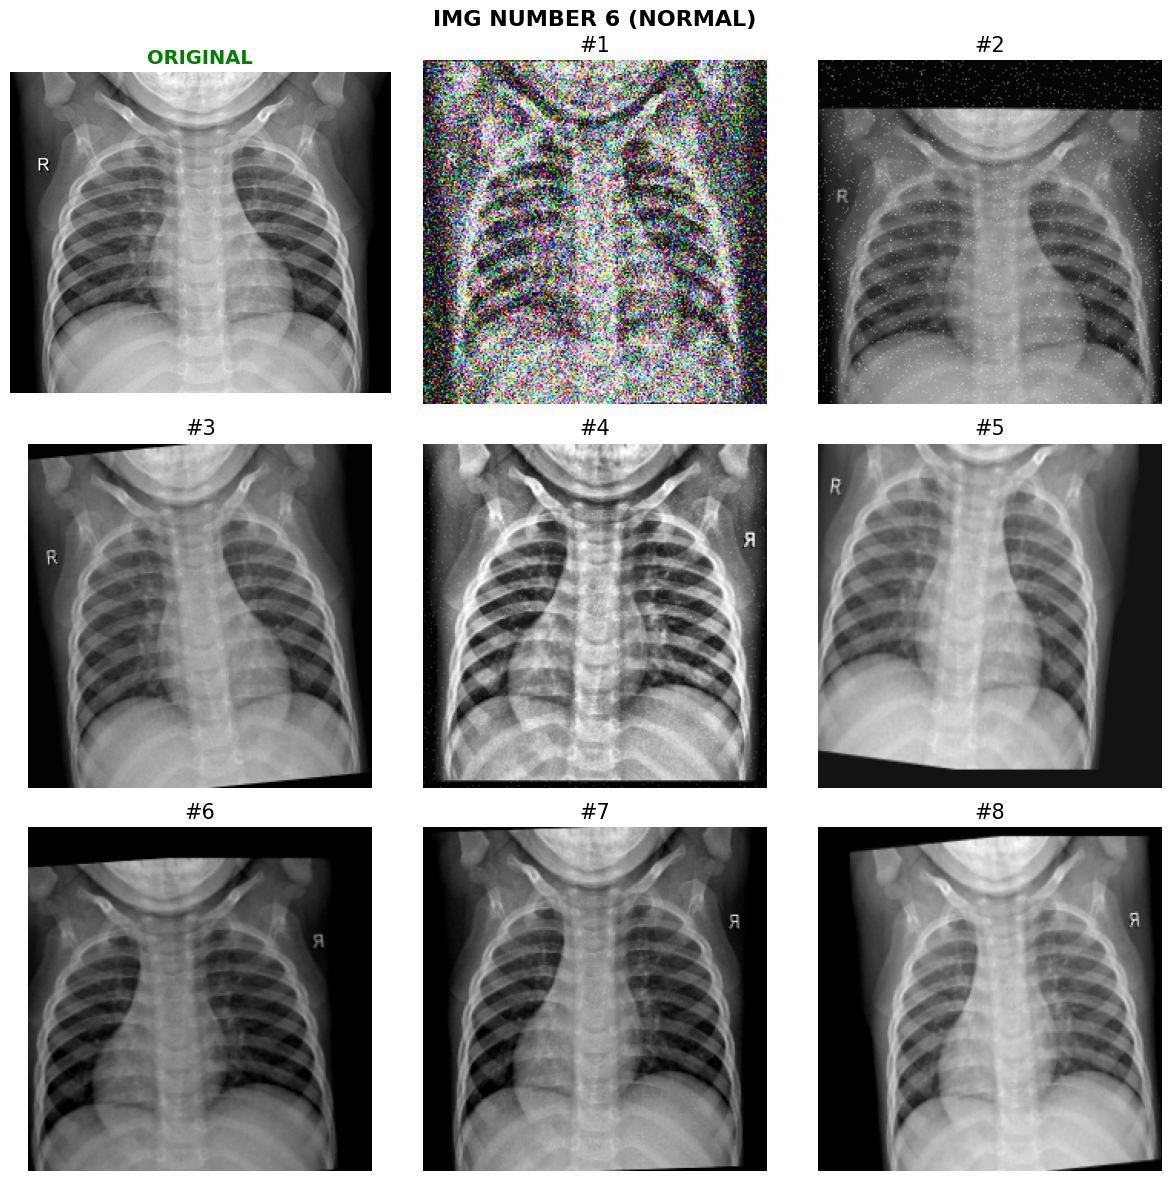


  DataLoaders ready!
  Batch size: 32
  Train batches: 148
  Val batches: 17
  Test batches: 20
Batch shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])

First 10 labels: [2, 2, 0, 2, 1, 2, 2, 0, 2, 1]
Label distribution: [9, 10, 13]


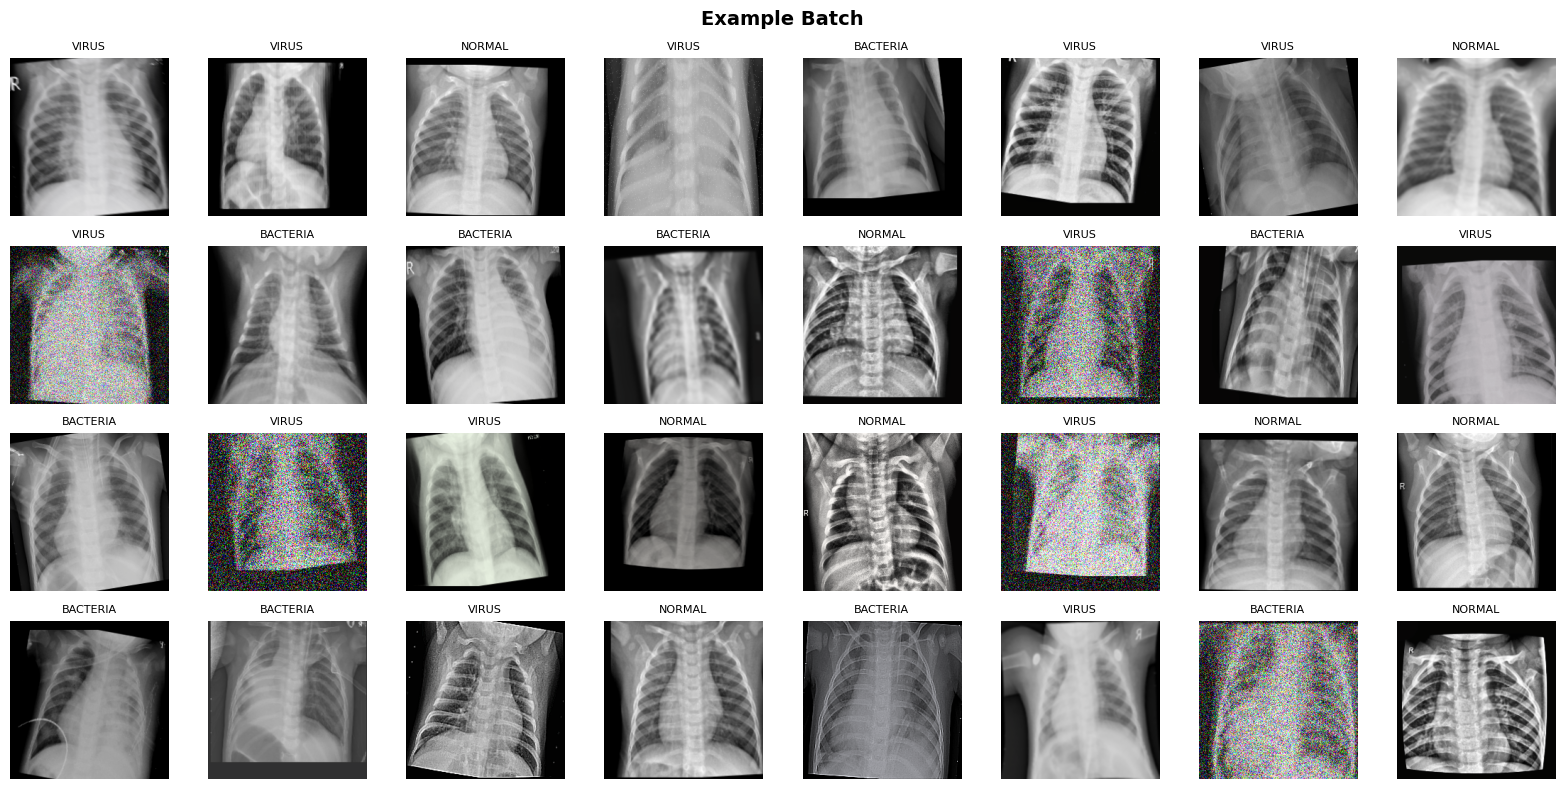

In [3]:
# Run the on-the-fly augmentation notebook
# This defines: dataset, train_data, val_data, test_data,
# as well as train_loader, val_loader, test_loader

%run "../on_the_fly_augmentation.ipynb"

## 2. Defining Random Forest and hyperparameters

- set model **hyperparameters** (number of trees, max depth, random state),
- define **NUM_CLASSES** = 3 (normal, bacteria, virus),
- Initialize **SMOTH** for class balancing
- initialize the **Random Forest** classifier for multiclass classification.

In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import joblib
import torch
from skimage.feature import hog

# Model hyperparameters
NUM_CLASSES = 3  # normal, bacteria, virus
N_ESTIMATORS = 1000
MAX_DEPTH = None 
RANDOM_STATE = 42

# Initialize StandardScaler for feature normalization
scaler = StandardScaler()

# Initialize SMOTE for class balancing
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=3)

# Initialize Random Forest Classifier with class balancing
rf_model = RandomForestClassifier(
    n_estimators=N_ESTIMATORS,
    max_depth=MAX_DEPTH,
    n_jobs=-1,
    min_samples_split=3,
    min_samples_leaf=1,
    criterion='gini',
    verbose=1,
    max_features="sqrt",
)

print("Random Forest Model Initialized")
print(f"  - NUM_CLASSES: {NUM_CLASSES}")
print(f"  - N_ESTIMATORS: {N_ESTIMATORS}")
print(f"  - MAX_DEPTH: {MAX_DEPTH}")
print(f"  - Features: HOG (8 orientations, 16x16 pixels)")
print(f"  - SMOTE: enabled (k_neighbors=3)")


Random Forest Model Initialized
  - NUM_CLASSES: 3
  - N_ESTIMATORS: 1000
  - MAX_DEPTH: None
  - Features: HOG (8 orientations, 16x16 pixels)
  - Class weight: balanced_subsample
  - SMOTE: enabled (k_neighbors=3)


## 3. Extract features and train Random Forest

- **extract image features** from the DataLoaders by converting images to flattened vectors,
- **fit** the Random Forest model on the training data,
- **evaluate** on validation and test sets,
- compute metrics: **accuracy**, **classification report**, **confusion matrix**.


In [17]:
def extract_features(loader):
    """Extract HOG features from images."""
    X_parts, y_parts = [], []

    for batch in loader:
        imgs = batch['image']
        labels = batch['label']

        imgs = imgs.detach().cpu().numpy()
        labels = labels.detach().cpu().numpy()

        for img, label in zip(imgs, labels):
            # Convert to grayscale
            img_gray = img[0]
            
            # Normalize to 0-1 range
            img_normalized = np.clip(img_gray, 0, 1)
            
            # Extract HOG features
            features = hog(
                img_normalized,
                orientations=12,
                pixels_per_cell=(8, 8),
                cells_per_block=(2, 2),
                block_norm='L2-Hys'
            )

            X_parts.append(features)
            y_parts.append(label)

    return np.array(X_parts), np.array(y_parts)

print("Extracting HOG features from train set...")
X_train, y_train = extract_features(train_loader)
print(f"  Train features shape: {X_train.shape}")
print(f"  Class distribution: {np.bincount(y_train.astype(int))}")

print("Extracting HOG features from validation set...")
X_val, y_val = extract_features(val_loader)
print(f"  Val features shape: {X_val.shape}")

print("Extracting HOG features from test set...")
X_test, y_test = extract_features(test_loader)
print(f"  Test features shape: {X_test.shape}")

# Apply StandardScaler for feature normalization
print("\nApplying StandardScaler...")
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)
print(f"  Scaled features shape: {X_train_scaled.shape}")

# Apply SMOTE
print("\nApplying SMOTE for class balancing...")
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)
print(f"  Balanced training shape: {X_train_balanced.shape}")
print(f"  Balanced class distribution: {np.bincount(y_train_balanced.astype(int))}")

# Train Random Forest
print("\nTraining Random Forest...")
rf_model.fit(X_train_balanced, y_train_balanced)
print("  Training complete!")

# Evaluate on validation set
y_val_pred = rf_model.predict(X_val_scaled)
val_accuracy = accuracy_score(y_val, y_val_pred)
print(f"\nValidation Accuracy: {val_accuracy:.4f}")

# Evaluate on test set
y_test_pred = rf_model.predict(X_test_scaled)
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {test_accuracy:.4f}")

print("\nTest Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=["NORMAL", "BACTERIA", "VIRUS"]))

print("\nTest Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))


Extracting HOG features from train set...
  Train features shape: (4705, 34992)
  Class distribution: [1175 2362 1168]
Extracting HOG features from validation set...
  Val features shape: (522, 34992)
Extracting HOG features from test set...
  Test features shape: (624, 34992)

Applying StandardScaler...
  Scaled features shape: (4705, 34992)

Applying SMOTE for class balancing...
  Balanced training shape: (7086, 34992)
  Balanced class distribution: [2362 2362 2362]

Training Random Forest...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    6.5s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:   31.3s
[Parallel(n_jobs=-1)]: Done 434 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 784 tasks      | elapsed:  2.3min
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:  3.0min finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 434 tasks      | elapsed:    0.0s


  Training complete!


[Parallel(n_jobs=8)]: Done 784 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 1000 out of 1000 | elapsed:    0.2s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 434 tasks      | elapsed:    0.0s



Validation Accuracy: 0.6954
Test Accuracy: 0.6763

Test Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.77      0.57      0.66       234
    BACTERIA       0.63      0.88      0.74       242
       VIRUS       0.67      0.50      0.57       148

    accuracy                           0.68       624
   macro avg       0.69      0.65      0.65       624
weighted avg       0.69      0.68      0.67       624


Test Confusion Matrix:
[[134  72  28]
 [ 19 214   9]
 [ 21  53  74]]


[Parallel(n_jobs=8)]: Done 784 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 1000 out of 1000 | elapsed:    0.2s finished


## 4. Model Statistics and Analysis

- compute detailed statistics and metrics,
- create visualization tables for performance analysis,
- display feature importance and class-wise metrics.


DETAILED CLASSIFICATION METRICS

Per-Class Metrics:
   Class  Precision   Recall  F1-Score  Support
  NORMAL   0.770115 0.572650  0.656863      234
BACTERIA   0.631268 0.884298  0.736661      242
   VIRUS   0.666667 0.500000  0.571429      148

Overall Accuracy: 0.6763
Macro Average F1: 0.6550
Weighted Average F1: 0.6550

Confusion Matrix (Detailed):
                 Pred NORMAL  Pred BACTERIA  Pred VIRUS
Actual NORMAL            134             72          28
Actual BACTERIA           19            214           9
Actual VIRUS              21             53          74

MODEL PARAMETERS
  n_estimators: 1000
  max_depth: None
  class_weight: balanced_subsample
  min_samples_split: 3
  min_samples_leaf: 1

TOP 10 FEATURE IMPORTANCE
  Feature 5586: 0.000784
  Feature 5491: 0.000478
  Feature 5683: 0.000463
  Feature 4411: 0.000418
  Feature 2970: 0.000404
  Feature 5719: 0.000393
  Feature 7988: 0.000369
  Feature 4219: 0.000367
  Feature 23868: 0.000337
  Feature 8024: 0.000333


✓ Visu

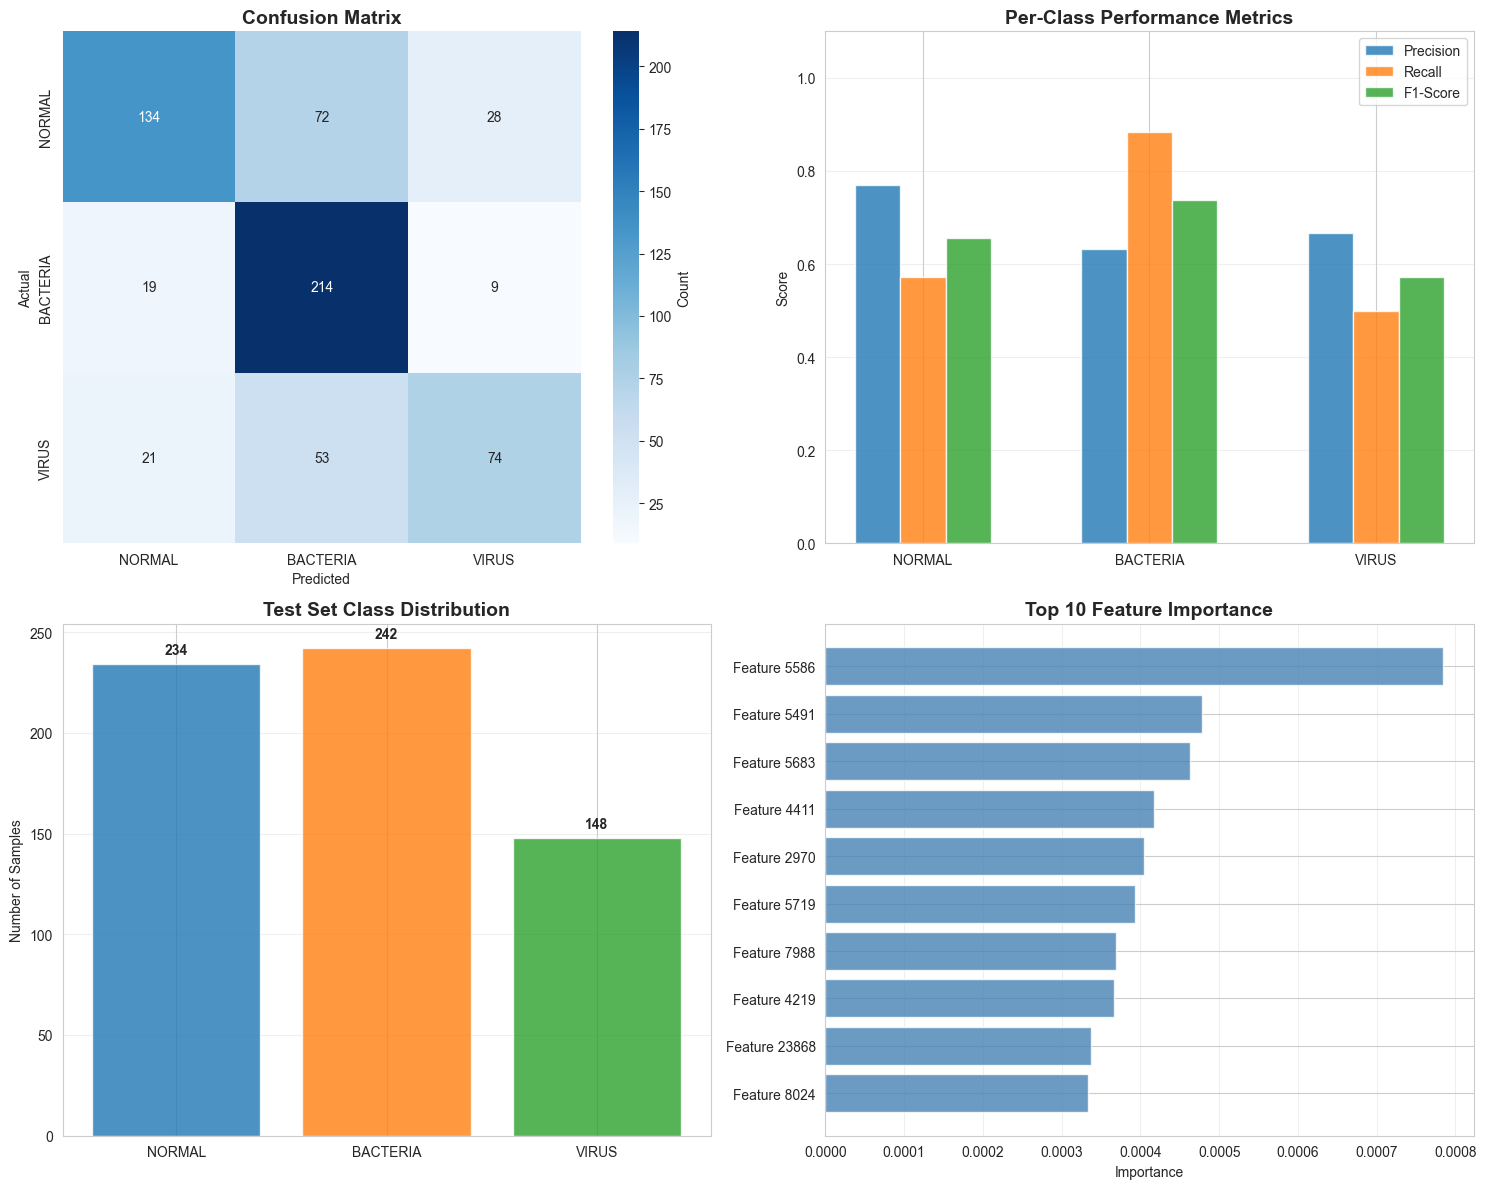

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix as cm

os.makedirs("./models", exist_ok=True)

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

# Detailed classification metrics
print("="*60)
print("DETAILED CLASSIFICATION METRICS")
print("="*60)

# Per-class metrics
precision, recall, f1, support = precision_recall_fscore_support(
    y_test, y_test_pred, labels=[0, 1, 2]
)

# Create metrics dataframe
metrics_df = pd.DataFrame({
    'Class': ['NORMAL', 'BACTERIA', 'VIRUS'],
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support
})

print("\nPer-Class Metrics:")
print(metrics_df.to_string(index=False))

# Overall metrics
print(f"\nOverall Accuracy: {test_accuracy:.4f}")
print(f"Macro Average F1: {metrics_df['F1-Score'].mean():.4f}")
print(f"Weighted Average F1: {precision_recall_fscore_support(y_test, y_test_pred)[2].mean():.4f}")

# Confusion Matrix as DataFrame
cm_matrix = cm(y_test, y_test_pred)
cm_df = pd.DataFrame(
    cm_matrix,
    columns=['Pred NORMAL', 'Pred BACTERIA', 'Pred VIRUS'],
    index=['Actual NORMAL', 'Actual BACTERIA', 'Actual VIRUS']
)

print("\nConfusion Matrix (Detailed):")
print(cm_df)

# Model parameters used
print("\n" + "="*60)
print("MODEL PARAMETERS")
print("="*60)
print(f"  n_estimators: {N_ESTIMATORS}")
print(f"  max_depth: {MAX_DEPTH}")
print(f"  class_weight: balanced_subsample")
print(f"  min_samples_split: 3")
print(f"  min_samples_leaf: 1")

# Feature importance
print("\n" + "="*60)
print("TOP 10 FEATURE IMPORTANCE")
print("="*60)
feature_importance = rf_model.feature_importances_
top_indices = np.argsort(feature_importance)[-10:][::-1]
for idx, importance in enumerate(feature_importance[top_indices]):
    print(f"  Feature {top_indices[idx]:3d}: {importance:.6f}")

print("\n" + "="*60)

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Confusion Matrix Heatmap
sns.heatmap(cm_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['NORMAL', 'BACTERIA', 'VIRUS'],
            yticklabels=['NORMAL', 'BACTERIA', 'VIRUS'],
            ax=axes[0, 0], cbar_kws={'label': 'Count'})
axes[0, 0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Actual')
axes[0, 0].set_xlabel('Predicted')

# 2. Per-Class Metrics Bar Chart
x = np.arange(len(metrics_df))
width = 0.2
axes[0, 1].bar(x - width, metrics_df['Precision'], width, label='Precision', alpha=0.8)
axes[0, 1].bar(x, metrics_df['Recall'], width, label='Recall', alpha=0.8)
axes[0, 1].bar(x + width, metrics_df['F1-Score'], width, label='F1-Score', alpha=0.8)
axes[0, 1].set_ylabel('Score')
axes[0, 1].set_title('Per-Class Performance Metrics', fontsize=14, fontweight='bold')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(metrics_df['Class'])
axes[0, 1].legend()
axes[0, 1].set_ylim([0, 1.1])
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Support Distribution
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
axes[1, 0].bar(metrics_df['Class'], metrics_df['Support'], color=colors, alpha=0.8)
axes[1, 0].set_ylabel('Number of Samples')
axes[1, 0].set_title('Test Set Class Distribution', fontsize=14, fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(metrics_df['Support']):
    axes[1, 0].text(i, v + 5, str(int(v)), ha='center', fontweight='bold')

# 4. Feature Importance Top 10
feature_names = [f'Feature {i}' for i in top_indices]
axes[1, 1].barh(feature_names, feature_importance[top_indices], color='steelblue', alpha=0.8)
axes[1, 1].set_xlabel('Importance')
axes[1, 1].set_title('Top 10 Feature Importance', fontsize=14, fontweight='bold')
axes[1, 1].invert_yaxis()
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('./models/classification_statistics.png', dpi=300, bbox_inches='tight')
print("\n✓ Visualization saved to: ./models/classification_statistics.png")
plt.show()


## 5. Save Model and Preprocessing Objects

- save the trained Random Forest model to disk,
- save the scaler and feature extraction pipeline,
- save metadata for model versioning.


In [ ]:
import os
from datetime import datetime

# Create models directory if it doesn't exist
model_dir = "./models"
os.makedirs(model_dir, exist_ok=True)

# Create timestamp for versioning
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Save the trained Random Forest model
model_path = os.path.join(model_dir, f"random_forest_model_{timestamp}.pkl")
joblib.dump(rf_model, model_path)
print(f"✓ Model saved to: {model_path}")

# Save the scaler
scaler_path = os.path.join(model_dir, f"scaler_{timestamp}.pkl")
joblib.dump(scaler, scaler_path)
print(f"✓ Scaler saved to: {scaler_path}")

# Save metadata
metadata = {
    'model_type': 'RandomForestClassifier',
    'timestamp': timestamp,
    'test_accuracy': float(test_accuracy),
    'validation_accuracy': float(val_accuracy),
    'n_estimators': N_ESTIMATORS,
    'max_depth': MAX_DEPTH,
    'class_weight': 'balanced_subsample',
    'num_classes': NUM_CLASSES,
    'classes': ['NORMAL', 'BACTERIA', 'VIRUS'],
    'feature_type': 'HOG (12 orientations, 8x8 pixels)',
    'training_samples': X_train_balanced.shape[0],
    'training_features': X_train_balanced.shape[1],
}

metadata_path = os.path.join(model_dir, f"metadata_{timestamp}.txt")
with open(metadata_path, 'w') as f:
    f.write("="*60 + "\n")
    f.write("RANDOM FOREST MODEL METADATA\n")
    f.write("="*60 + "\n\n")
    for key, value in metadata.items():
        f.write(f"{key}: {value}\n")
    f.write("\n" + "="*60 + "\n")
    f.write("TEST METRICS\n")
    f.write("="*60 + "\n")
    f.write(classification_report(y_test, y_test_pred, target_names=["NORMAL", "BACTERIA", "VIRUS"]))

print(f"✓ Metadata saved to: {metadata_path}")

# List of saved files
print("\n" + "="*60)
print("SAVED FILES")
print("="*60)
for file in os.listdir(model_dir):
    if timestamp in file:
        file_path = os.path.join(model_dir, file)
        file_size = os.path.getsize(file_path) / (1024*1024)
        print(f"  {file} ({file_size:.2f} MB)")

print("\n✓ Model and preprocessing objects successfully saved!")


NameError: name 'rf_model' is not defined

## 6. Test Model on New Samples

- load saved model and scaler,
- make predictions on individual test samples,
- display predictions with confidence scores,
- visualize test images with predictions.


In [ ]:
from PIL import Image as PILImage
from tqdm import tqdm

class_names = ["NORMAL", "BACTERIA", "VIRUS"]
class_colors = {
    "NORMAL": "#2ca02c",    
    "BACTERIA": "#ff7f0e",  
    "VIRUS": "#d62728"
}

def predict_single_sample(img_array, model, scaler, sample_idx=None):
    """
    Make prediction on a single image.
    
    Args:
        img_array: Grayscale image (normalized 0-1)
        model: Trained Random Forest model
        scaler: Fitted StandardScaler
        sample_idx: Optional sample index for display
    
    Returns:
        dict with prediction info
    """
    # Extract HOG features
    features = hog(
        img_array,
        orientations=12,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys'
    ).reshape(1, -1)
    
    # Scale features
    features_scaled = scaler.transform(features)
    
    # Get prediction and probabilities
    prediction = model.predict(features_scaled)[0]
    probabilities = model.predict_proba(features_scaled)[0]
    
    return {
        'prediction': int(prediction),
        'class_name': class_names[int(prediction)],
        'probabilities': probabilities,
        'confidence': probabilities[int(prediction)]
    }

# Test on random samples from test set
print("="*70)
print("TESTING MODEL ON RANDOM TEST SAMPLES")
print("="*70)

num_samples_to_test = 6
sample_indices = np.random.choice(len(test_data), num_samples_to_test, replace=False)

# Create figure for predictions
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for plot_idx, sample_idx in enumerate(sample_indices):
    sample = test_data[sample_idx]
    img_tensor = sample['image']
    true_label = sample['label']
    
    # Convert to numpy
    img_np = img_tensor.numpy()
    img_grayscale = img_np[0]  # Get grayscale channel
    
    # Make prediction
    result = predict_single_sample(img_grayscale, rf_model, scaler, sample_idx)
    
    # Show image
    axes[plot_idx].imshow(img_grayscale, cmap='gray')
    
    # Prepare title with prediction info
    true_class = class_names[true_label]
    pred_class = result['class_name']
    confidence = result['confidence'] * 100
    
    is_correct = true_label == result['prediction']
    title_color = "green" if is_correct else "red"
    
    title = f"True: {true_class}\nPred: {pred_class} ({confidence:.1f}%)"
    axes[plot_idx].set_title(title, fontsize=11, fontweight='bold', color=title_color)
    axes[plot_idx].axis('off')    # Vérifier la vraie distribution
    true_class_dist = np.bincount(y_test)
    print(f"Distribution vraie test: NORMAL={true_class_dist[0]}, BACTERIA={true_class_dist[1]}, VIRUS={true_class_dist[2]}")
    
    # Print detailed results
    print(f"\nSample {plot_idx + 1}:")
    print(f"  True Label: {true_class}")
    print(f"  Prediction: {pred_class}")
    print(f"  Confidence: {confidence:.2f}%")
    print(f"  Probabilities:")
    for i, (cls_name, prob) in enumerate(zip(class_names, result['probabilities'])):
        print(f"    - {cls_name}: {prob*100:.2f}%")
    print(f"  Result: {'✓ CORRECT' if is_correct else '✗ INCORRECT'}")

plt.tight_layout()
plt.savefig('./models/test_predictions.png', dpi=300, bbox_inches='tight')
print("\n✓ Test predictions visualization saved to: ./models/test_predictions.png")
plt.show()

# Summary statistics on subset of test set
print("\n" + "="*70)
print("BATCH PREDICTION SUMMARY (First 200 Samples)")
print("="*70)

max_samples = min(200, len(test_data))
correct_predictions = 0
predictions_by_class = {i: {'correct': 0, 'total': 0} for i in range(NUM_CLASSES)}

indices = np.random.choice(len(test_data), max_samples, replace=False)

for i in tqdm(indices, desc="Processing samples"):
    sample = test_data[i]
    img_tensor = sample['image']
    true_label = sample['label']
    
    img_np = img_tensor.numpy()
    img_grayscale = img_np[0]
    
    result = predict_single_sample(img_grayscale, rf_model, scaler)
    
    predictions_by_class[true_label]['total'] += 1
    if true_label == result['prediction']:
        correct_predictions += 1
        predictions_by_class[true_label]['correct'] += 1

print(f"\nTotal Test Samples Evaluated: {max_samples}")
print(f"Correct Predictions: {correct_predictions}")
print(f"Overall Accuracy: {correct_predictions / max_samples * 100:.2f}%")

print("\nPer-Class Results:")
for i, class_name in enumerate(class_names):
    correct = predictions_by_class[i]['correct']
    total = predictions_by_class[i]['total']
    accuracy = correct / total * 100 if total > 0 else 0
    print(f"  {class_name}: {correct}/{total} ({accuracy:.2f}%)")

print("\n" + "="*70)


TESTING MODEL ON RANDOM TEST SAMPLES


NameError: name 'test_data' is not defined